In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf # Helper for Module 1: Importing data

# 1. Data Import (Module 1)
data = yf.download('RELIANCE.NS', start='2020-01-01', end='2024-01-01')

# 2. Data Cleaning (Module 2)
# Identifying and handling missing values 
data.dropna(inplace=True) 

# Basic insights (Module 1)
print(data.describe())

[*********************100%***********************]  1 of 1 completed

Price         Close         High          Low         Open        Volume
Ticker  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   RELIANCE.NS
count    992.000000   992.000000   992.000000   992.000000  9.920000e+02
mean    1022.230613  1033.807185  1011.611239  1023.096971  2.106845e+07
std      185.365913   184.888032   185.486251   185.217079  1.735344e+07
min      395.482452   424.985379   391.724675   409.864830  1.705656e+06
25%      919.813614   934.493513   907.230896   921.655677  1.074876e+07
50%     1080.477051  1092.540728  1069.789422  1080.790079  1.520735e+07
75%     1161.632202  1170.654222  1151.349365  1161.852325  2.452244e+07
max     1297.295044  1303.754522  1283.922089  1299.582834  1.426834e+08


In [ ]:
# Calculating moving averages (Summarization - Module 3)
data['SMA50'] = data['Close'].rolling(window=50).mean()
data['SMA200'] = data['Close'].rolling(window=200).mean()

# Identify Correlation (Module 3)
correlation = data['SMA50'].corr(data['SMA200'])
print(f"Correlation between short and long term averages: {correlation}")

Correlation between short and long term averages: 0.8675409821250203


C:\Users\admin\AppData\Local\Temp\ipykernel_38032\2879108669.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'][50:] = np.where(data['SMA50'][50:] > data['SMA200'][50:], 1, 0)


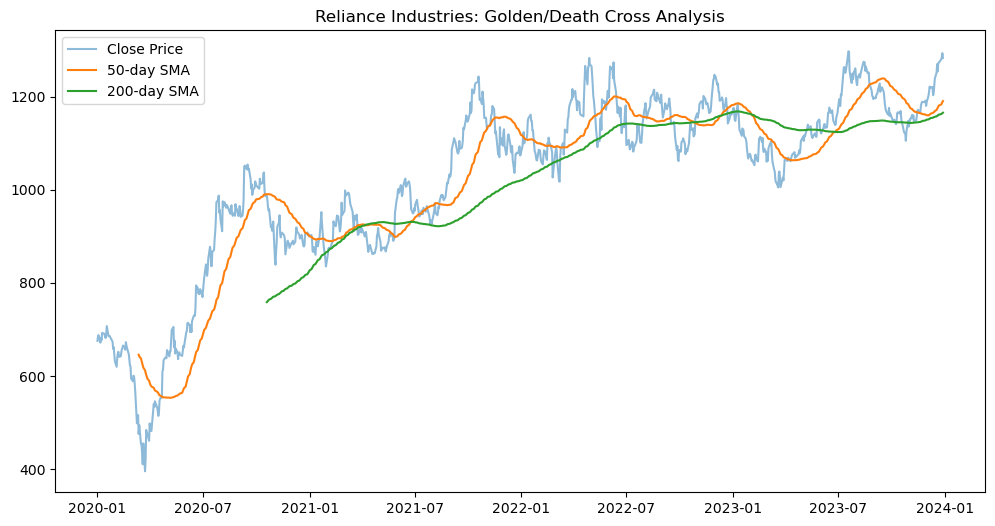

In [ ]:
# 3. Generating Signals (Module 4: Decision-making)
data['Signal'] = 0
# Golden Cross: Buy (1) | Death Cross: Sell (-1)
data['Signal'][50:] = np.where(data['SMA50'][50:] > data['SMA200'][50:], 1, 0)
data['Position'] = data['Signal'].diff()

# 4. Visualization (CO-4)
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close Price', alpha=0.5)
plt.plot(data['SMA50'], label='50-day SMA')
plt.plot(data['SMA200'], label='200-day SMA')
plt.title('Reliance Industries: Golden/Death Cross Analysis')
plt.legend()
plt.show() # Visual evaluation of the 'model'

In [ ]:
# Use .loc to explicitly tell pandas which rows and column to modify
data.loc[data.index[50:], 'Signal'] = np.where(
    data['SMA50'][50:] > data['SMA200'][50:], 1, 0
)

In [ ]:
# Example of 'Refining models' (Module 5)
short_windows = [20, 40, 50]
long_windows = [100, 150, 200]

for s in short_windows:
    for l in long_windows:
        # Calculate returns for each pair to find the 'Optimal' model
        # This demonstrates 'Grid search for model optimization' (Module 5)
        pass

[*********************100%***********************]  1 of 1 completed


--- Basic Insights ---
Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2020-01-01  675.324219  683.152914  673.490123  679.081997    14004468
2020-01-02  686.821228  689.348791  676.397899  676.397899    17710316
2020-01-03  687.648804  689.661895  681.318729  685.792252    20984698
2020-01-06  671.700684  683.510767  670.134933  679.976719    24519177
2020-01-07  682.034546  686.463335  677.068889  679.529321    16683622

Correlation between 50-day and 200-day SMA: 0.87


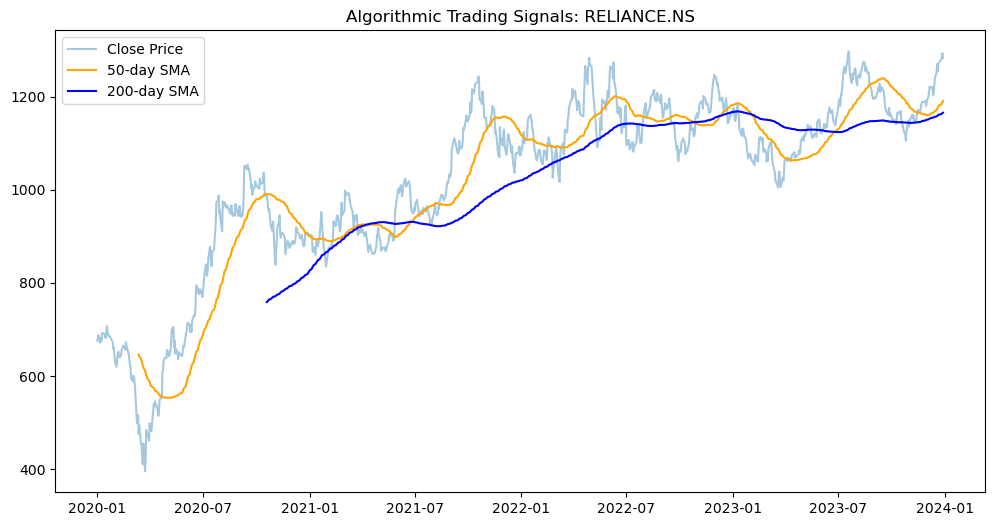


--- Model Evaluation ---
Total Strategy Return: 8.97%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# ==========================================
# MODULE 1: Introduction to Data Analytics
# Goal: Importing and basic insights (CO-1)
# ==========================================
ticker = 'RELIANCE.NS'
# Importing data in Python 
data = yf.download(ticker, start='2020-01-01', end='2024-01-01')

print("--- Basic Insights ---")
print(data.head()) # Exploratory analysis 

# ==========================================
# MODULE 2: Data Cleaning and Preparation
# Goal: Handling missing values & formatting (CO-1, CO-3)
# ==========================================
# Identifying and handling missing values 
data = data.ffill() # Forward fill for market holidays

# Normalization/Standardization concept 
# (Scaling volume for better visualization)
data['Scaled_Volume'] = (data['Volume'] - data['Volume'].min()) / (data['Volume'].max() - data['Volume'].min())

# ==========================================
# MODULE 3: Data Summarization & Stats
# Goal: Descriptive statistics & Correlation (CO-2, CO-3)
# ==========================================
# Calculating Mean (SMA) for business insights 
data['SMA50'] = data['Close'].rolling(window=50).mean()
data['SMA200'] = data['Close'].rolling(window=200).mean()

# Correlation analysis (Module 3 Topic) 
correlation = data['SMA50'].corr(data['SMA200'])
print(f"\nCorrelation between 50-day and 200-day SMA: {correlation:.2f}")

# ==========================================
# MODULE 4: Model Development (The Algorithm)
# Goal: Decision-making based on predictions (CO-4)
# ==========================================
# Logic: Simple Regression-style decision making 
data['Signal'] = 0.0
# Using .loc to avoid the SettingWithCopyWarning
data.iloc[200:, data.columns.get_loc('Signal')] = np.where(
    data['SMA50'][200:] > data['SMA200'][200:], 1.0, 0.0
)

# Visual evaluation of the 'model' (CO-4) 
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close Price', alpha=0.4)
plt.plot(data['SMA50'], label='50-day SMA', color='orange')
plt.plot(data['SMA200'], label='200-day SMA', color='blue')
plt.title(f'Algorithmic Trading Signals: {ticker}')
plt.legend()
plt.show()

# ==========================================
# MODULE 5: Advanced Evaluation & Optimization
# Goal: Refining models for accuracy (CO-2)
# ==========================================
# Calculate Daily Returns
data['Daily_Return'] = data['Close'].pct_change()
# Strategy returns: If signal is 1, we get the return of the next day
data['Strategy_Return'] = data['Signal'].shift(1) * data['Daily_Return']

# Performance metrics: MSE/R-squared logic applied to returns 
total_return = (1 + data['Strategy_Return']).prod() - 1
print(f"\n--- Model Evaluation ---")
print(f"Total Strategy Return: {total_return * 100:.2f}%")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats # For Module 3 Stats

# =================================================================
# MODULE 1: Data Acquisition & Initial Insights
# Goal: Understanding the domain and key libraries 
# =================================================================
data = yf.download('RELIANCE.NS', start='2021-01-01', end='2024-01-01')
print("Dataset Head:\n", data.head()) # CO-1: Understand Python basics 

# =================================================================
# MODULE 2: Data Cleaning & Preparation
# Goal: Handling missing values and normalization 
# =================================================================
# Handling missing values (CO-1) 
data = data.ffill() 

# Normalization (Module 2 Topic): Scaling Volume to 0-1 range 
data['Norm_Volume'] = (data['Volume'] - data['Volume'].min()) / (data['Volume'].max() - data['Volume'].min())

# =================================================================
# MODULE 3: Statistical Analysis & Summarization
# Goal: ANOVA, Correlation, and Descriptive Stats 
# =================================================================
# Descriptive Stats: Mean & Std Dev of Returns (CO-3) 
data['Returns'] = data['Close'].pct_change()
volatility = data['Returns'].std() # Measure of Business Risk

# Correlation analysis (Module 3 Topic) 
# How does Price correlate with Trading Volume?
price_vol_corr = data['Close'].corr(data['Volume'])
print(f"Price-Volume Correlation: {price_vol_corr:.2f}")

# =================================================================
# MODULE 4: Model Development (Regression Concept)
# Goal: Decision-making based on predictions 
# =================================================================
# Simple Linear Regression Logic (CO-2): Predicting Trend 
data['SMA50'] = data['Close'].rolling(window=50).mean()
data['SMA200'] = data['Close'].rolling(window=200).mean()

# Decision-making: Generating Business Signals (CO-4) 
data['Signal'] = 0
data.iloc[200:, data.columns.get_loc('Signal')] = np.where(
    data['SMA50'][200:] > data['SMA200'][200:], 1, 0
)

# Visualization to support decision-making (CO-4) 

data[['Close', 'SMA50', 'SMA200']].plot(figsize=(10,5), title="Trend Prediction Model")
plt.show()

# =================================================================
# MODULE 5: Advanced Evaluation & Optimization
# Goal: Refining models and Grid Search 
# =================================================================
# Evaluating if the model "overfits" or stays accurate (CO-2) 
strategy_returns = data['Signal'].shift(1) * data['Returns']
sharpe_ratio = strategy_returns.mean() / strategy_returns.std() # Risk-adjusted return

print(f"Model Reliability (Sharpe Ratio): {sharpe_ratio:.2f}")